In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from SupernovaDataset.config import DATA_VARIANCE_SCALE
from ModelEvaluation.abc import hist_with_error_bars

In [3]:
bounds = []
bound_names = []
final_bound_values = []
bound_counts = []
i_z_x_s = []

for st in os.listdir('.'):
    if '_bound' in st and os.path.exists(f'{st}/{st}s.npy'):
        bound_names.append(st[:-6])
        bound = np.load(f'{st}/{st}s.npy', allow_pickle=True)
        if "BA" in st:
            bound = bound + 3.02
        i_z_x = np.load(f'{st}/i_z_x.npy', allow_pickle=True)
        bound_counts.append(bound.shape[0])
        bounds.append(bound)
        final_bound_values.append(bound[:, -1])
        i_z_x_s.append(i_z_x)
print(bound_names, [len(b) for b in final_bound_values])

['BA_KDE', 'BA_NF', 'DV', 'MINE', 'NWJ', 'TUBA'] [40, 5, 40, 62, 20, 30]


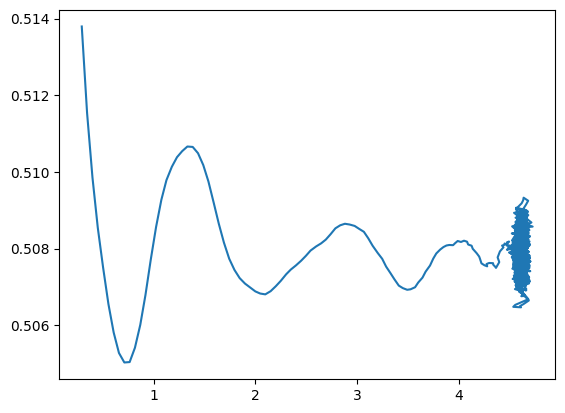

In [4]:
plt.plot(bounds[1][0] + 3.02, i_z_x_s[1][0])

In [5]:
true_fi = 2500 * DATA_VARIANCE_SCALE**-2
true_mi = 0.5*np.log(1 + 25*true_fi)
print(f"True MI: {true_mi} | true FI: {true_fi}")

True MI: 9.433483926490393 | true FI: 6250000.0


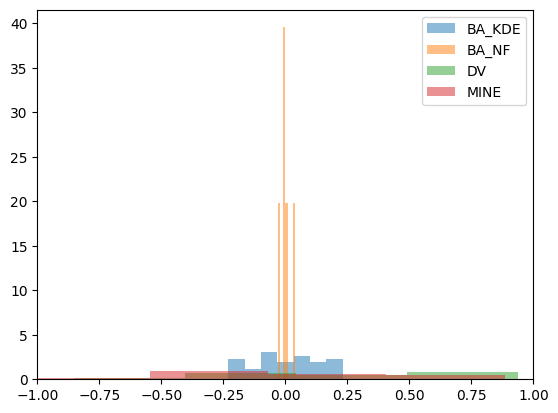

In [6]:
for i, final_bound in enumerate(final_bound_values):
    plt.hist(
        (final_bound - final_bound.mean()), # / final_bound.std(),
        bins = 7,
        # title='Distribution of Final Estimates',
        # xlabel='Estimate',
        # ylabel='Frequency',
        label=bound_names[i],
        density=True,
        alpha=0.5
    )
    if bound_names[i] == "MINE":
        break
    # break
plt.xlim([-1., 1])
plt.legend()
plt.show()

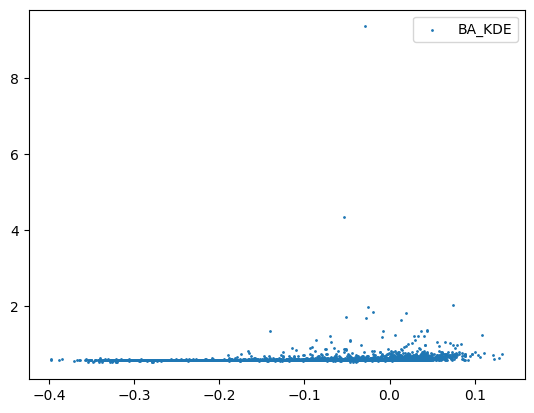

In [7]:
for i, bound_name in enumerate(bound_names):
    plt.scatter(bounds[i][0], i_z_x_s[i][0], s=1, label=bound_name)
    break
plt.legend()
